# IBP barycentre vs. pairwise optimal transport

In [16]:
import time
import warnings
from itertools import combinations

import numpy as np
import scipy.sparse as sp
from scipy.sparse.csgraph import dijkstra
import matplotlib.pyplot as plt
import ot

warnings.filterwarnings("ignore")
rng_global = np.random.default_rng(0)
print("POT", ot.__version__)

POT 0.9.6.post1


## 1. Solvers


In [ ]:
def ibp_barycenter_with_costs(A, C, reg, weights, maxiter=500, tol=1e-6,
                              K=None, M=None):
    n, N = A.shape

    if K is None or M is None:
        Cf = np.asarray(C, dtype=float)
        finite = np.isfinite(Cf)
        Csafe = np.where(finite, Cf, 0.0)
        K = np.where(finite, np.exp(-Csafe / reg), 0.0)
        M = np.where(finite, K * Csafe, 0.0)

    eps = 1e-300
    u = np.ones((n, N))
    v = np.array(A, dtype=float, copy=True)
    beta = np.full(n, 1.0 / n)

    for _ in range(maxiter):
        v = A / np.maximum(K @ u, eps)
        Kv = K @ v
        log_beta = (np.log(np.maximum(Kv, eps)) * weights).sum(axis=1)
        beta_new = np.exp(log_beta)

        total = beta_new.sum()
        if not np.isfinite(total) or total <= 0.0:
            break
        beta_new /= total

        converged = np.max(np.abs(beta_new - beta)) < tol
        beta = beta_new
        u = beta[:, None] / np.maximum(Kv, eps)
        if converged:
            break

    costs = (u * (M @ v)).sum(axis=0)
    return beta, costs


def col(A, k):
    return np.ascontiguousarray(A[:, k], dtype=float)


def lp_barycenter_with_costs(A, C, weights):
    C = np.ascontiguousarray(C, dtype=float)
    A = np.ascontiguousarray(A, dtype=float)
    beta = np.ascontiguousarray(ot.lp.barycenter(A, C, weights), dtype=float)
    N = A.shape[1]
    costs = np.array([ot.emd2(col(A, k), beta, C) for k in range(N)])
    return beta, costs


def pairwise_exact(A, C):
    C = np.ascontiguousarray(C, dtype=float)
    N = A.shape[1]
    return {(i, j): float(ot.emd2(col(A, i), col(A, j), C))
            for i, j in combinations(range(N), 2)}


def pairwise_entropic(A, C, reg, maxiter=500, tol=1e-6):
    C = np.ascontiguousarray(C, dtype=float)
    N = A.shape[1]
    return {(i, j): float(ot.sinkhorn2(col(A, i), col(A, j), C, reg,
                                       method="sinkhorn_log",
                                       numItermax=maxiter, stopThr=tol))
            for i, j in combinations(range(N), 2)}

### Contiguity self-check

POT's Cython entry points require C-contiguous arrays. Column slices of a 2-D
array are strided views and fail this. The `col()` helper above copies. This
cell fails loudly now rather than 200 lines in.

In [18]:
_A = np.ascontiguousarray(np.random.default_rng(0).random((6, 3)))
_A /= _A.sum(axis=0)
_C = np.ascontiguousarray(np.random.default_rng(1).random((6, 6)))
_C = (_C + _C.T) / 2
np.fill_diagonal(_C, 0.0)

print("raw column contiguous? ", _A[:, 0].flags["C_CONTIGUOUS"])
print("col() contiguous?      ", col(_A, 0).flags["C_CONTIGUOUS"])
try:
    ot.emd2(_A[:, 0], _A[:, 1], _C)
    print("this POT build tolerates strided columns (it copies internally)")
except ValueError as err:
    print("this POT build rejects strided columns:", err)
print("via col():", ot.emd2(col(_A, 0), col(_A, 1), _C))

raw column contiguous?  False
col() contiguous?       True
this POT build rejects strided columns: ndarray is not C-contiguous
via col(): 0.21476512898056158


## 2. Curvature


In [19]:
def ORC_bary(costs, N):
    return float(1.0 - costs.sum() / (N - 1))


def ORC_pair(pw):
    return float(1.0 - np.mean(list(pw.values())))

## 3. Test problems


In [20]:
def random_hypergraph(n_nodes=200, n_edges=150, size_lo=3, size_hi=8, seed=0):
    rng = np.random.default_rng(seed)
    e2n, n2e = {}, {i: set() for i in range(n_nodes)}
    n_blocks = max(2, n_nodes // 40)
    block = rng.integers(0, n_blocks, size=n_nodes)
    for e in range(n_edges):
        k = int(rng.integers(size_lo, size_hi + 1))
        pool = (np.where(block == rng.integers(0, n_blocks))[0]
                if rng.random() < 0.85 else np.arange(n_nodes))
        if len(pool) < k:
            pool = np.arange(n_nodes)
        members = frozenset(rng.choice(pool, size=k, replace=False).tolist())
        if len(members) < 2:
            continue
        eid = f"e{e}"
        e2n[eid] = members
        for u in members:
            n2e[u].add(eid)
    return e2n, n2e


def clique_expansion(e2n, n_nodes):
    rows, cols = [], []
    for col, members in enumerate(e2n.values()):
        for u in members:
            rows.append(u); cols.append(col)
    inc = sp.coo_matrix((np.ones(len(rows), np.int32), (rows, cols)),
                        shape=(n_nodes, max(len(e2n), 1))).tocsr()
    W = (inc @ inc.T).tocsr()
    W.setdiag(0); W.eliminate_zeros()
    A = W.copy(); A.data = np.ones_like(A.data)
    return A


def node_measure(e2n, n2e, i, alpha=0.01):
    inc = n2e.get(i, ())
    if not inc:
        return {i: 1.0}
    mu = {i: alpha} if alpha > 0 else {}
    share = (1.0 - alpha) / len(inc)
    for e in inc:
        members = e2n[e]
        n_other = len(members) - 1
        if n_other <= 0:
            continue
        w = share / n_other
        for o in members:
            if o != i:
                mu[o] = mu.get(o, 0.0) + w
    return mu


def bfs_ball(indptr, indices, src, depth):
    frontier = np.unique(np.asarray(src, dtype=np.int64))
    visited = frontier
    for _ in range(int(depth)):
        if frontier.size == 0:
            break
        starts, ends = indptr[frontier], indptr[frontier + 1]
        if int((ends - starts).sum()) == 0:
            break
        nbrs = np.unique(np.concatenate(
            [indices[s:e] for s, e in zip(starts, ends)])).astype(np.int64)
        frontier = nbrs[np.isin(nbrs, visited, assume_unique=True, invert=True)]
        if frontier.size:
            visited = np.union1d(visited, frontier)
    return visited


def build_instance(e2n, n2e, Adj, eid, alpha=0.01, radius=5, max_support=None,
                   seed=0):
    """Return (A_marginals, C) for one hyperedge, or None if too small."""
    nodes_e = sorted(e2n[eid])
    N = len(nodes_e)
    if N < 3:
        return None
    measures = {i: node_measure(e2n, n2e, i, alpha) for i in nodes_e}

    base = set(nodes_e)
    for i in nodes_e:
        base.update(measures[i])

    indptr, indices = Adj.indptr, Adj.indices
    per = [bfs_ball(indptr, indices, np.array([s]), 2) for s in nodes_e]
    vals, counts = np.unique(np.concatenate(per), return_counts=True)
    support = sorted(base | set(vals[counts >= 2].tolist()))

    if max_support and len(support) > max_support:
        rng = np.random.default_rng(seed)
        keep = set(base)
        extra = [u for u in support if u not in keep]
        room = max_support - len(keep)
        if room > 0 and extra:
            sel = rng.choice(len(extra), size=min(room, len(extra)),
                             replace=False)
            keep |= {extra[s] for s in sel}
        support = sorted(keep)

    idx = np.array(support, dtype=np.int64)
    ball = bfs_ball(indptr, indices, idx, radius // 2)
    sub = Adj[ball][:, ball]
    local = np.searchsorted(ball, idx)
    D = dijkstra(sub, directed=False, indices=local, unweighted=True,
                 limit=radius)[:, local]
    C = np.where(np.isfinite(D), D, float(radius + 1)).astype(float)

    pos = {u: k for k, u in enumerate(support)}
    Am = np.zeros((len(support), N))
    for col, i in enumerate(nodes_e):
        for t, w in measures[i].items():
            if t in pos:
                Am[pos[t], col] = w
    Am /= np.maximum(Am.sum(axis=0), 1e-300)
    return np.ascontiguousarray(Am), np.ascontiguousarray(C)


E2N, N2E = random_hypergraph(seed=1)
ADJ = clique_expansion(E2N, 200)
print(f"{len(E2N)} hyperedges, sizes {min(map(len, E2N.values()))}"
      f"-{max(map(len, E2N.values()))}")

150 hyperedges, sizes 3-8


## 4. One edge, in detail

In [21]:
eid = next(e for e in E2N if len(E2N[e]) >= 6)
A, C = build_instance(E2N, N2E, ADJ, eid, max_support=100)
N = A.shape[1]
w = np.full(N, 1.0 / N)
REG = 0.1          # <-- the module default

b_ibp, c_ibp = ibp_barycenter_with_costs(A, C, REG, w)
b_lp,  c_lp  = lp_barycenter_with_costs(A, C, w)
pw_ex = pairwise_exact(A, C)

print(f"edge {eid}: N={N} sources, support n={A.shape[0]}, cost range 0-{C.max():.0f}\n")
print(f"  IBP  total cost {c_ibp.sum():8.4f}   ORC {ORC_bary(c_ibp, N):+.4f}")
print(f"  LP   total cost {c_lp.sum():8.4f}   ORC {ORC_bary(c_lp,  N):+.4f}")
print(f"  IBP relative error on total cost: {(c_ibp.sum()/c_lp.sum() - 1)*100:+.2f}%")
print(f"  TV(beta_IBP, beta_LP): {0.5*np.abs(b_ibp - b_lp).sum():.4f}\n")
print(f"  pairwise (exact) mean W: {np.mean(list(pw_ex.values())):.4f}"
      f"   ORC_pair {ORC_pair(pw_ex):+.4f}")

edge e0: N=6 sources, support n=84, cost range 0-3

  IBP  total cost   2.3661   ORC +0.5268
  LP   total cost   2.2362   ORC +0.5528
  IBP relative error on total cost: +5.81%
  TV(beta_IBP, beta_LP): 0.1206

  pairwise (exact) mean W: 0.5962   ORC_pair +0.4038


## 5. Accuracy vs. regularisation

In [23]:
regs = [1.0, 0.5, 0.25, 0.1, 0.05, 0.025]
k_true = ORC_bary(c_lp, N)

rows = []
for r in regs:
    b, cst = ibp_barycenter_with_costs(A, C, r, w)
    rows.append(dict(reg=r, cost=cst.sum(), IBP_ORC=ORC_bary(cst, N),
                     rel_err=cst.sum()/c_lp.sum() - 1,
                     IBP_ORC_error=ORC_bary(cst, N) - k_true,
                     tv=0.5*np.abs(b - b_lp).sum()))

print(f"{'reg':>7} {'total cost':>11} {'rel.err':>9} {'ORC IBP':>9} "
      f"{'ORC IBP err':>10} {'TV(beta)':>9}")
print("-" * 60)
for d in rows:
    print(f"{d['reg']:7.3f} {d['cost']:11.4f} {d['rel_err']*100:8.2f}% "
          f"{d['IBP_ORC']:+9.4f} {d['IBP_ORC_error']:+10.4f} {d['tv']:9.4f}")
print("-" * 60)
print(f"{'LP':>7} {c_lp.sum():11.4f} {'--':>9} {k_true:+9.4f}")

    reg  total cost   rel.err   ORC IBP ORC IBP err  TV(beta)
------------------------------------------------------------
  1.000      8.8358   295.13%   -0.7672    -1.3199    0.5493
  0.500      6.4584   188.81%   -0.2917    -0.8444    0.4053
  0.250      3.6114    61.50%   +0.2777    -0.2750    0.2476
  0.100      2.3661     5.81%   +0.5268    -0.0260    0.1206
  0.050      2.2604     1.08%   +0.5479    -0.0048    0.0636
  0.025      2.2303    -0.26%   +0.5539    +0.0012    0.0430
------------------------------------------------------------
     LP      2.2362        --   +0.5528


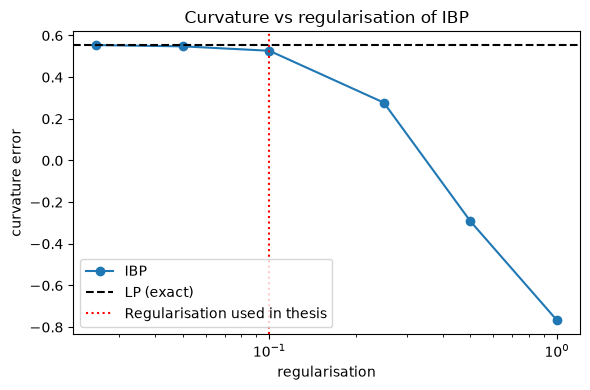

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.semilogx([d["reg"] for d in rows], [d["IBP_ORC"] for d in rows], "o-",
               label="IBP")
ax.axhline(k_true, ls="--", c="k", label="LP (exact)")
ax.axvline(0.1, ls=":", c="r", label="Regularisation used in thesis")
ax.set_xlabel("regularisation"); ax.set_ylabel("curvature error")
ax.set_title("Curvature vs regularisation of IBP"); ax.legend()# ; ax[1].grid(alpha=.8)
plt.tight_layout(); plt.show()

## 6. Do the two curvatures agree?

Run every edge through IBP, LP, and the pairwise route, and correlate.

In [26]:
from scipy.stats import spearmanr, pearsonr

MAX_SUPPORT = 90        # keeps the LP reference affordable
N_EDGES = 40

recs = []
cand = [e for e in E2N if len(E2N[e]) >= 3]
for eid_ in cand[:N_EDGES]:
    inst = build_instance(E2N, N2E, ADJ, eid_, max_support=MAX_SUPPORT)
    if inst is None:
        continue
    Ai, Ci = inst
    Ni = Ai.shape[1]
    wi = np.full(Ni, 1.0 / Ni)
    _, ci_ibp = ibp_barycenter_with_costs(Ai, Ci, REG, wi)
    _, ci_lp = lp_barycenter_with_costs(Ai, Ci, wi)
    pw = pairwise_exact(Ai, Ci)
    recs.append(dict(edge=eid_, N=Ni, n=Ai.shape[0],
                     k_ibp=kappa_bary(ci_ibp, Ni),
                     k_lp=kappa_bary(ci_lp, Ni),
                     k_pair=kappa_pair(pw)))

k_ibp = np.array([r["k_ibp"] for r in recs])
k_lp = np.array([r["k_lp"] for r in recs])
k_pr = np.array([r["k_pair"] for r in recs])

print(f"{len(recs)} edges\n")
print("IBP vs LP  (same quantity, is IBP accurate?)")
print(f"   mean signed error {np.mean(k_ibp - k_lp):+.4f}   "
      f"max |error| {np.max(np.abs(k_ibp - k_lp)):.4f}")
print(f"   Pearson {pearsonr(k_ibp, k_lp)[0]:.4f}   "
      f"Spearman {spearmanr(k_ibp, k_lp).statistic:.4f}\n")
print("LP vs pairwise  (different quantities, are they similar?)")
print(f"   Pearson {pearsonr(k_lp, k_pr)[0]:.4f}   "
      f"Spearman {spearmanr(k_lp, k_pr).statistic:.4f}\n")
print("IBP vs pairwise  (what you'd actually be swapping)")
print(f"   Pearson {pearsonr(k_ibp, k_pr)[0]:.4f}   "
      f"Spearman {spearmanr(k_ibp, k_pr).statistic:.4f}")

40 edges

IBP vs LP  (same quantity, is IBP accurate?)
   mean signed error -0.0283   max |error| 0.0563
   Pearson 0.9980   Spearman 0.9921

LP vs pairwise  (different quantities, are they similar?)
   Pearson 0.9705   Spearman 0.9403

IBP vs pairwise  (what you'd actually be swapping)
   Pearson 0.9762   Spearman 0.9452


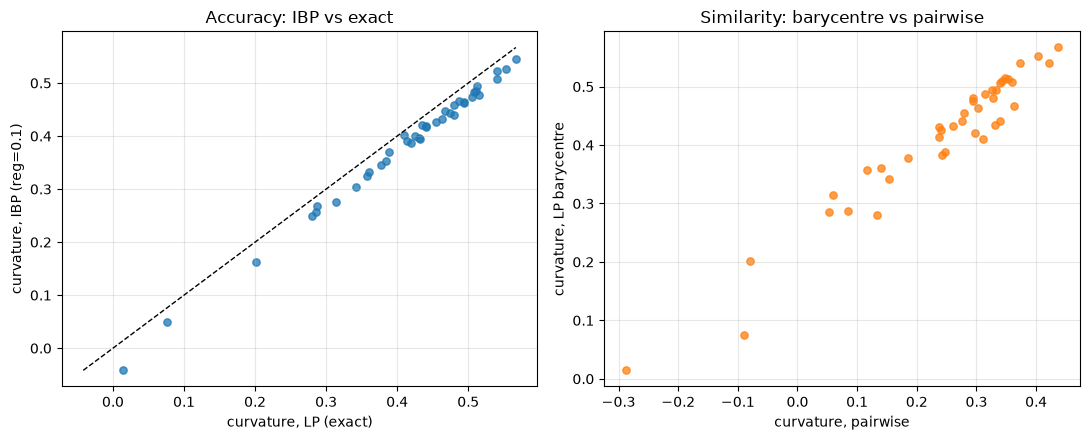

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
lo = min(k_ibp.min(), k_lp.min()); hi = max(k_ibp.max(), k_lp.max())
ax[0].scatter(k_lp, k_ibp, s=28, alpha=.75)
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].set_xlabel("curvature, LP (exact)"); ax[0].set_ylabel(f"curvature, IBP (reg={REG})")
ax[0].set_title("Accuracy: IBP vs exact"); ax[0].grid(alpha=.3)

ax[1].scatter(k_pr, k_lp, s=28, alpha=.75, c="tab:orange")
ax[1].set_xlabel("curvature, pairwise"); ax[1].set_ylabel("curvature, LP barycentre")
ax[1].set_title("Similarity: barycentre vs pairwise"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. Convergence

In [29]:
def ibp_check(A, C, reg, weights, maxiter=500, tol=1e-6):
    """Rerun the same iteration, reporting iterations used and marginal error."""
    n, N = A.shape
    K = np.exp(-C / reg)
    eps = 1e-300
    u = np.ones((n, N))
    beta = np.full(n, 1.0 / n)
    iters = 0
    for it in range(maxiter):
        iters = it + 1
        v = A / np.maximum(K @ u, eps)
        Kv = K @ v
        beta_new = np.exp((np.log(np.maximum(Kv, eps)) * weights).sum(axis=1))
        tot = beta_new.sum()
        if not np.isfinite(tot) or tot <= 0:
            break
        beta_new /= tot
        done = np.max(np.abs(beta_new - beta)) < tol
        beta = beta_new
        u = beta[:, None] / np.maximum(Kv, eps)
        if done:
            break
    # row-marginal error of P_k = diag(v_k) K diag(u_k)
    row_err = max(np.abs(((v[:, k][:, None] * K) * u[:, k][None, :]).sum(1)
                         - A[:, k]).sum() for k in range(N))
    return iters, iters < maxiter, row_err


print(f"{'reg':>7} {'iters':>7} {'converged':>10} {'max row err':>12} "
      f"{'cost':>9} {'vs LP':>9}")
print("-" * 60)
for r in regs:
    it, ok, rerr = ibp_check(A, C, r, w)
    _, cst = ibp_barycenter_with_costs(A, C, r, w)
    print(f"{r:7.3f} {it:7d} {str(ok):>10} {rerr:12.2e} "
          f"{cst.sum():9.4f} {cst.sum() - c_lp.sum():+9.4f}")
print("-" * 60)
print("a negative 'vs LP' means the plan is infeasible, not that IBP beat the LP")

    reg   iters  converged  max row err      cost     vs LP
------------------------------------------------------------
  1.000       4       True     2.08e-05    8.8358   +6.5996
  0.500       7       True     6.58e-05    6.4584   +4.2222
  0.250      13       True     2.47e-04    3.6114   +1.3752
  0.100     100       True     1.11e-04    2.3661   +0.1299
  0.050     349       True     3.45e-04    2.2604   +0.0242
  0.025     500      False     5.95e-03    2.2303   -0.0059
------------------------------------------------------------
a negative 'vs LP' means the plan is infeasible, not that IBP beat the LP
